## Practical 11 

## Logistic Regression in Machine Learning

Logistic Regression is a supervised learning algorithm used when the output (dependent variable) is categorical, such as:

Yes / No, 0 / 1, True / False, Spam / Not Spam

Example:

Predict whether a vehicle has a fault (1) or not (0) based on features like mileage, engine condition

### Question 1: Predict House Price 

In [ ]:
pip install numpy pandas matplotlib scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 

In [6]:
data = { 
'Size': [1, 2, 3], 
'Price': [150, 200, 250] 
} 

df = pd.DataFrame(data)

# Prepare the data
X = df[['Size']]
y = df['Price']

# Train the model
model = LinearRegression()
model.fit(X, y)

# View the Learned Coefficients 
print("Intercept (β₀):", model.intercept_) 
print("Coefficient (β₁):", model.coef_[0]) 

# Predict on training data 
y_pred = model.predict(X) 

# Predict on new data 
size = [[2.5]] 
predicted_price = model.predict(size) 
print("Predicted price of a 2.5 (1000 sq. ft) house: ", predicted_price[0]) 

Intercept (β₀): 100.00000000000003
Coefficient (β₁): 49.999999999999986
Predicted price of a 2.5 (1000 sq. ft) house:  225.0


f:\AI\Practical 11\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Question 2: Salary vs Experience


Final Parameters: θ0 = 28.3275, θ1 = 7.2695
Predicted salary of someone with 5 years of experience: 64.67484126826461


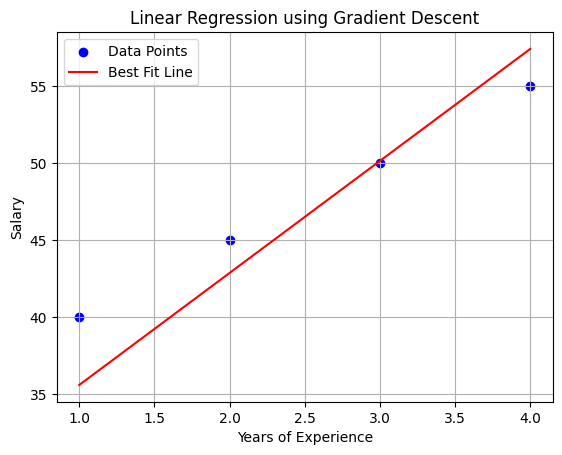

In [ ]:
X = np.array([1, 2, 3, 4 ]) 
y = np.array([40, 45, 50, 55]) 

def compute_cost(X, y, theta0, theta1): 
    m = len(y) 
    predictions = theta0 + theta1 * X 
    cost = (1 / m) * np.sum((predictions - y) ** 2) 
    return cost 

# Implement Gradient Descent to find best fit line
def gradient_descent(X, y, alpha=0.01, iterations=1000): 
    m = len(y) 
    theta0 = 0 
    theta1 = 0 
    cost_history = [] 

    for i in range(iterations): 
        predictions = theta0 + theta1 * X 
        error = predictions - y 

        # Compute gradients 
        # Gradient = how much the cost changes when we change a parameter
        grad0 = (1 / m) * np.sum(error) 
        grad1 = (1 / m) * np.sum(error * X) 

        # Update parameters 
        theta0 -= alpha * grad0 
        theta1 -= alpha * grad1 

        # Track cost 
        cost = compute_cost(X, y, theta0, theta1) 
        cost_history.append(cost) 
        
    return theta0, theta1, cost_history 

theta0, theta1, cost_history = gradient_descent(X, y, alpha=0.01, iterations=1000) 
print(f"\nFinal Parameters: θ0 = {theta0:.4f}, θ1 = {theta1:.4f}") 

def predict(x): 
    return theta0 + theta1 * x 

print("Predicted salary of someone with 5 years of experience:", predict(5))

# Visualize the data and the best fit line
plt.scatter(X, y, color='blue', label='Data Points') 
plt.plot(X, theta0 + theta1 * X, color='red', label='Best Fit Line') 
plt.title("Linear Regression using Gradient Descent") 
plt.xlabel("Years of Experience") 
plt.ylabel("Salary") 
plt.legend() 
plt.grid(True) 
plt.show() 


### Example: Predicting Admission Based on Exam Scores

In [ ]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, confusion_matrix 
import pandas as pd 

# Sample data 
data = pd.DataFrame({ 
'score1': [85, 60, 90, 45], 
'score2': [80, 55, 92, 50], 
'admitted': [1, 0, 1, 0] 
}) 

X = data[['score1', 'score2']] #independent variables
y = data['admitted'] #dependent variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25) 

model = LogisticRegression() 
# Internally it will learn z=b0​+b1​x1​+b2​x2​ and then apply sigmoid function to get probabilities.

model.fit(X_train, y_train) 

predictions = model.predict(X_test) # predicts 0 or 1 based probabilities

print("Accuracy:", accuracy_score(y_test, predictions)) 
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

Accuracy: 1.0
Confusion Matrix:
 [[1]]


f:\AI\Practical 11\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Accuracy = correct predictions / total predictions 

confusion matrix 

                TN     FN  ​

                ​FP     TP

                    got 1 prediction correct
	​


### Example 2


Loads a built-in dataset from sklearn. 

Goal: predict whether a tumor is: Malignant (0) -> cancerous or Benign (1) -> non-cancerous

#### Load and Explore Dataset 

In [ ]:
from sklearn.datasets import load_breast_cancer 
import pandas as pd 

data = load_breast_cancer() 
df = pd.DataFrame(data.data, columns=data.feature_names) # rows -> samples, columns -> features
df['target'] = data.target # target variable (0 or 1) indicating if the tumor is malignant or benign
print(df.head()) 

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [ ]:
# print(df.shape)

(569, 31)


#### Split Data into Train and Test Sets

In [11]:
from sklearn.model_selection import train_test_split 

X = df.drop('target', axis=1) # removes the target column from the dataset axis=1 means column-wise
y = df['target'] # output variable (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Train Logistic Regression Model

In [13]:
from sklearn.linear_model import LogisticRegression 

model = LogisticRegression(max_iter=10000) 
model.fit(X_train, y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Make Predictions and Evaluate the Model

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

y_pred = model.predict(X_test) 

print('Accuracy:', accuracy_score(y_test, y_pred)) 
print(confusion_matrix(y_test, y_pred)) 
print(classification_report(y_test, y_pred))

Accuracy: 0.956140350877193
[[39  4]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



TP      FN

FP      TN

Classification report:

class 0

    Precision (0.97): When model predicts 0, it is correct 97% of the time

    Recall (0.91): It correctly finds 91% of all actual 0s

    Support (43): There are 43 real samples of class 0

class 1

    Precision (0.95): When model predicts 1, it is correct 95% of the time

    Recall (0.99): It catches 99% of all actual 1s (very strong)

    Support (71): 71 real samples of class 1



#### Predict on New Data (Optional)

iloc[0] -> first row of the test dataset

.values -> converts the row to a numpy array

.reshape(1, -1) -> reshapes the array to a 2D array with one row

(number_of_samples, number_of_features) -> 1 = one sample , -1 = automatically calculate number of features

In [ ]:
# Predict using the first instance from the test set 
import numpy as np 

sample = X_test.iloc[0].values.reshape(1, -1) 

prediction = model.predict(sample) 

print('Predicted class:', prediction) 

Predicted class: [1]


f:\AI\Practical 11\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
